[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py_ua/syn_ua_08_synchronization.ipynb)


# 08. Синхронізація і колективна фазова динаміка

_Магістерський курс «Вступ до синергетики» · українська версія_

> **Провідне питання:** Як слабкий зв'язок між неоднаковими осциляторами може породити спільний макроскопічний ритм?

**Як працювати з ноутбуком.** Виконуйте комірки послідовно, згори донизу. Якщо не зазначено інше, усі параметри безрозмірні. Пояснюйте зміст кожної діагностики: сама лише ефектна траєкторія ще не доводить самоорганізації.


## Результати навчання

Після опрацювання модуля ви зможете:

- пояснити, як податлива спільна опора зв'язує годинники Гюйгенса та метрономи на рухомій платформі;
- вивести й перевірити умову фазового захоплення для пари осциляторів;
- вивести середньопольову форму моделі Курамото;
- обчислювати й тлумачити комплексний параметр порядку;
- відрізняти когерентність скінченної системи від справжнього колективного переходу.


## Необхідний вступ: фазова редукція

Стійкий осцилятор повертається на ту саму замкнену орбіту через період $T$. Фаза $\theta\in[0,2\pi)$ позначає положення на циклі й зростає з власною частотою $\omega=2\pi/T$. Слабкі збурення переважно зсувають фазу, оскільки відхили поперек циклу згасають.

Фазова редукція відкидає амплітудні перехідні процеси й залишає рівняння $\dot\theta_i=\omega_i+$ зв'язок. Вона точна для слабкого зв'язку та стійких циклів, але може порушуватися поблизу амплітудних нестійкостей, загибелі коливань або сильного зовнішнього впливу. Комплексне середнє $N^{-1}\sum_j e^{i\theta_j}$ є векторною сумою на одиничному колі: випадкові фази взаємно гасяться, а вирівняні — підсилюються.


## Годинники Гюйгенса: синхронізація через рухому опору

У 1665 році Християн Гюйгенс описав «дивну симпатію» двох маятникових годинників на спільній опорі: після перехідного процесу їхні маятники зберігали майже протилежні фази. Сучасний навчальний аналог — пара автоколивних метрономів на легкій платформі, здатній рухатися горизонтально. Такі метрономи зазвичай переходять до синфазного руху, хоча за інших параметрів опори, тертя та спускового механізму стійким може бути й протифазний стан. **Маятники не «притягують» фази безпосередньо.** Кожен осцилятор розгойдує опору, а її прискорення діє на обидва осцилятори й забезпечує обмін енергією та імпульсом.

Мінімальна механічна модель із кутами маятників $q_i$ і зміщенням опори $x$ має структуру

$$ml^2\ddot q_i+b\dot q_i+mgl\sin q_i
=\tau_{\mathrm{esc},i}(q_i,\dot q_i)-ml\ddot x\cos q_i,$$

$$(M+2m)\ddot x+\Gamma\dot x+kx
=-ml\sum_{i=1}^2\left(\ddot q_i\cos q_i-\dot q_i^2\sin q_i\right).$$

Спусковий механізм компенсує втрати енергії й утворює стійкий граничний цикл. Без цього активного елемента ми мали б затухаючі маятники, а не годинники чи метрономи. Локальний Mathematica-архів курсу (`metronome.nb`, `metronome0.nb` і `Two Metronomes.nb`) розвиває саме модель зі спільною рухомою підвіскою та діагностує синхронізацію за відносною фазою; відеозаписи дають експериментальну перевірку. Опублікований ноутбук не залежить від цих локальних файлів і тому лишається придатним для Colab.

За слабкого зв'язку амплітудні відхили згасають, і механічна система редукується до рівняння різниці фаз

$$\dot\delta=\Delta\omega-2K\sin(\delta-\delta_0),\qquad \delta=\theta_2-\theta_1.$$

Значення $\delta_0=0$ описує притягальну синфазну гілку, а $\delta_0=\pi$ — протифазну. Захоплення фаз існує за умови $|\Delta\omega|\leq 2K$, а стійкий фазовий зсув дорівнює $\delta^*=\delta_0+\sin^{-1}(\Delta\omega/2K)$. Редукована модель прозоро передбачає захоплення та проковзування фази, але не може визначити $\delta_0$ з конструкції приладу: для цього потрібна повна механіка опори й спускового механізму.


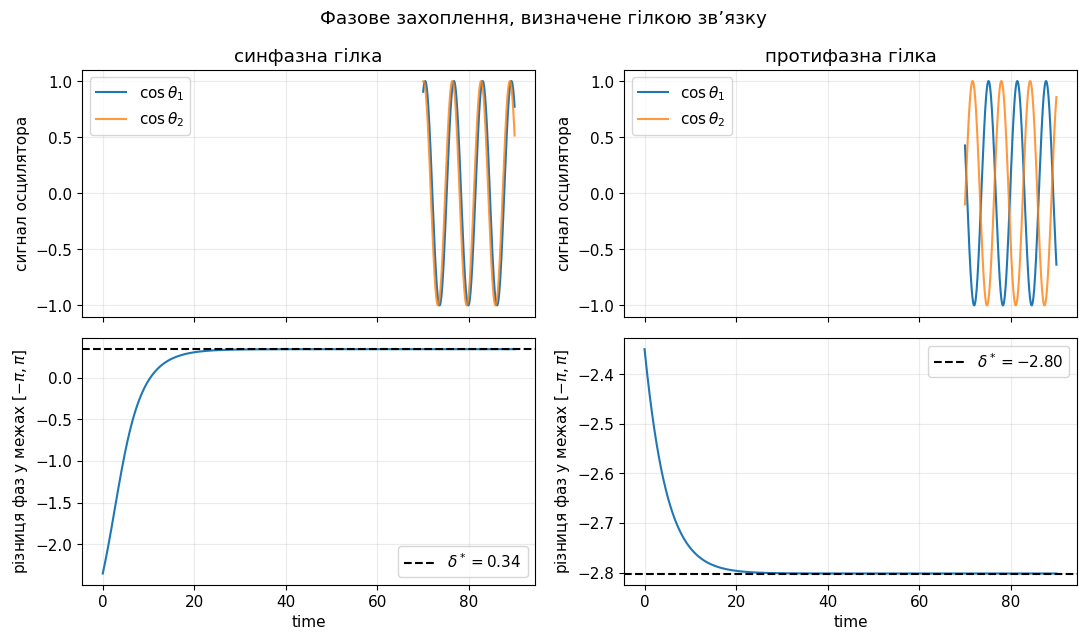

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def phase_locked_pair(delta0, delta_omega=0.08, K=0.12,
                      omega_mean=1.0, dt=0.02, duration=90.0):
    # Фазова модель пари автоколивних осциляторів у наближенні слабкого зв'язку.
    t = np.arange(0.0, duration + dt, dt)
    theta = np.empty((2, t.size))
    theta[:, 0] = (0.0, -2.35)
    omega = np.array([omega_mean - delta_omega/2,
                      omega_mean + delta_omega/2])
    for n in range(t.size - 1):
        delta = theta[1, n] - theta[0, n]
        interaction = K*np.sin(delta - delta0)
        theta[:, n + 1] = theta[:, n] + dt*np.array([
            omega[0] + interaction,
            omega[1] - interaction,
        ])
    wrapped_delta = np.angle(np.exp(1j*(theta[1] - theta[0])))
    return t, theta, wrapped_delta

cases = [(0.0, "синфазна гілка"), (np.pi, "протифазна гілка")]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")
for col, (delta0, label) in enumerate(cases):
    t, theta, delta = phase_locked_pair(delta0)
    tail = t > 70
    axes[0, col].plot(t[tail], np.cos(theta[0, tail]), label=r"$\cos\theta_1$")
    axes[0, col].plot(t[tail], np.cos(theta[1, tail]), label=r"$\cos\theta_2$", alpha=0.8)
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("сигнал осцилятора")
    axes[0, col].legend()
    target = np.angle(np.exp(1j*(delta0 + np.arcsin(0.08/(2*0.12)))))
    axes[1, col].plot(t, delta)
    axes[1, col].axhline(target, color="k", ls="--", label=fr"$\delta^*={target:.2f}$")
    axes[1, col].set(xlabel="time", ylabel="різниця фаз у межах $[-π,π]$")
    axes[1, col].legend()
plt.suptitle("Фазове захоплення, визначене гілкою зв’язку")
plt.tight_layout()
plt.show()


## Параметр порядку Курамото

Модель глобально зв'язаних фаз має вигляд

$$\dot\theta_i=\omega_i+\frac{K}{N}\sum_j\sin(\theta_j-\theta_i).$$

Визначимо $Z=re^{i\psi}=N^{-1}\sum_j e^{i\theta_j}$. Тоді

$$\dot\theta_i=\omega_i+Kr\sin(\psi-\theta_i).$$

Взаємодію багатьох тіл закодовано колективним полем $Z$. Це особливо прозорий приклад циклічної причинності: фази породжують параметр порядку, а він у відповідь діє на кожну фазу. Для симетричного одновершинного розподілу власних частот $g$ поріг нескінченної системи дорівнює $K_c=2/[\pi g(0)]$.


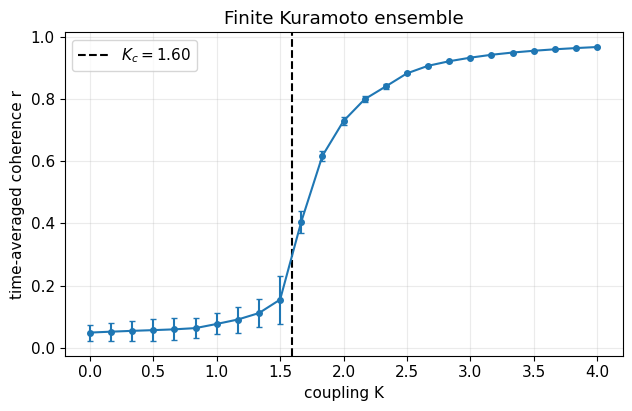

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def kuramoto(K, omega, theta0, dt=0.03, steps=3500, burn=1500):
    theta = theta0.copy()
    r_history = []
    for n in range(steps):
        Z = np.mean(np.exp(1j*theta))
        theta += dt*(omega + K*np.abs(Z)*np.sin(np.angle(Z)-theta))
        if n >= burn:
            r_history.append(abs(np.mean(np.exp(1j*theta))))
    return np.mean(r_history), np.std(r_history), theta

N = 400
omega = rng.normal(0, 1, N)
theta0 = rng.uniform(0, 2*np.pi, N)
K_values = np.linspace(0, 4, 25)
stats = np.array([kuramoto(K, omega, theta0)[:2] for K in K_values])
Kc_theory = 2/(np.pi*(1/np.sqrt(2*np.pi)))

plt.errorbar(K_values, stats[:, 0], yerr=stats[:, 1], marker="o", ms=4, capsize=2)
plt.axvline(Kc_theory, color="k", ls="--", label=fr"$K_c={Kc_theory:.2f}$")
plt.xlabel("coupling K")
plt.ylabel("time-averaged coherence r")
plt.title("Finite Kuramoto ensemble")
plt.legend()
plt.show()


## Оцінюване завдання

**Частина A.** Проскануйте розстройку $\Delta\omega$ та силу зв'язку $K$ у фазовій моделі годинників/метрономів. Класифікуйте захоплення за довгочасовим дрейфом $\delta$, побудуйте межу області захоплення й порівняйте її з $|\Delta\omega|=2K$. Поясніть, чому лише з цього розрахунку не можна встановити, синфазний чи протифазний стан обере реальна опора.

**Частина B.** Повторіть сканування Курамото для $N=100,400,1600$, щоразу використовуючи незалежні вибірки власних частот. Оцініть скінченно-розмірний фоновий рівень когерентності нижче порога, задайте операційне визначення $K_c(N)$ і обережно екстраполюйте його до теоретичного значення.

Подання має містити чітке твердження, його математичне або фізичне обґрунтування, числові свідчення та принаймні одне обмеження висновку.


## Література та атрибуція

**Основне читання з локальної бібліотеки:** Kuramoto, *Chemical Oscillations, Waves, and Turbulence*; Mikhailov, *Foundations of Synergetics I*, розділи про коливальні середовища. Механічні виведення та експерименти подано також в авторському архіві `metronome.nb`, `metronome0.nb`, `Two Metronomes.nb`, `synchro1.mp4` і `synchro2.mp4`.

**Перевірені вебджерела:**
- [Physics World: The secret of the synchronized pendulums](https://physicsworld.com/a/the-secret-of-the-synchronized-pendulums/)
- [Pantaleone: Synchronization of metronomes](https://doi.org/10.1119/1.1501118)
- [Bennett et al.: Huygens's clocks](https://doi.org/10.1098/rspa.2001.0888)
- [Oliveira and Melo: Huygens synchronization of two clocks](https://doi.org/10.1038/srep11548)
- [Kuramoto, Chemical Oscillations, Waves, and Turbulence](https://doi.org/10.1007/978-3-642-69689-3)

Локальні книги є наданими матеріалами курсу. Вебпосилання мають додатковий характер; їх перевірено 08.09.2026.
